<a href="https://colab.research.google.com/github/DksMh/data-mining/blob/main/01_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터마이닝 프로젝트 — 파이프라인
### 안명현 (2025720536)
**주제:** 환율·시장지수·변동성이 한국·미국 기술주 ETF 수익률에 미치는 영향 비교

---
### 실행 순서
1. STEP 1 — 라이브러리 설치
2. STEP 2 — yfinance 데이터 수집 (9개 티커)
3. STEP 3 — Google Trends CSV 병합
4. STEP 4 — 전처리 (수익률 변환 + 원화 환산)
5. STEP 5 — 시장 국면 라벨링
6. STEP 6 — VIF 다중공선성 진단
7. STEP 7 — 상관관계 히트맵

> ⚠️ STEP 3 실행 전에 Google Trends CSV를 Google Drive에 업로드해야 합니다.

In [1]:
# ════════════════════════════════════════════════════════
# STEP 1 — 라이브러리 설치 및 임포트
# ════════════════════════════════════════════════════════
!pip install yfinance statsmodels -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings, time
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Google Colab)
!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})

print('✅ 라이브러리 로드 완료')

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 라이브러리 로드 완료


In [2]:
# STEP 2 — yfinance 데이터 수집 (수정된 코드)

TICKERS = {
    'KODEX_반도체': '091160.KS',
    'TIGER_200IT':  '157490.KS',
    'SOXX':         'SOXX',
    'QQQ':          'QQQ',
    'USDKRW':       'KRW=X',
    'SP500':        '^GSPC',
    'KOSPI':        '^KS11',
    'VIX':          '^VIX',
    'WTI':          'CL=F',
}

START = '2022-01-01'
END   = pd.Timestamp.today().strftime('%Y-%m-%d')
print(f'수집 기간: {START} ~ {END}\n')

frames = {}
for name, ticker in TICKERS.items():
    try:
        # ✅ 최신 yfinance 방식
        obj = yf.Ticker(ticker)
        df  = obj.history(start=START, end=END, interval='1wk', auto_adjust=True)

        if df.empty:
            print(f'❌ {name} ({ticker}): 데이터 없음')
            continue

        frames[name] = df['Close'].rename(name)
        print(f'✅ {name:15} | {len(df):3}주 | {df.index[0].date()} ~ {df.index[-1].date()}')
        time.sleep(0.5)

    except Exception as e:
        print(f'❌ {name} ({ticker}): {e}')

print(f'\n수집 성공: {len(frames)}/9개')

수집 기간: 2022-01-01 ~ 2026-04-20

✅ KODEX_반도체       | 224주 | 2022-01-03 ~ 2026-04-13
✅ TIGER_200IT     | 224주 | 2022-01-03 ~ 2026-04-13
✅ SOXX            | 224주 | 2022-01-01 ~ 2026-04-11
✅ QQQ             | 224주 | 2022-01-01 ~ 2026-04-11
✅ USDKRW          | 225주 | 2022-01-01 ~ 2026-04-18
✅ SP500           | 224주 | 2022-01-01 ~ 2026-04-11
✅ KOSPI           | 224주 | 2022-01-03 ~ 2026-04-13
✅ VIX             | 224주 | 2022-01-01 ~ 2026-04-11
✅ WTI             | 224주 | 2022-01-01 ~ 2026-04-11

수집 성공: 9/9개


In [3]:
# STEP 3 시간 기준 결합 (주간 리샘플링으로 날짜 통일)

# 각 ticker를 주간 단위로 리샘플링 후 결합
resampled = {}
for name, series in frames.items():
    s = series.copy()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    # 주의 마지막 거래일(금요일) 기준으로 주간 집계
    resampled[name] = s.resample('W-FRI').last()

raw = pd.DataFrame(resampled)
raw.index.name = 'date'

print(f'결합 결과: {raw.shape[0]}행 × {raw.shape[1]}열')
print(f'\n결측치:\n{raw.isnull().sum()}')
print(f'\n기간: {raw.index[0].date()} ~ {raw.index[-1].date()}')
raw.tail(3)

결합 결과: 225행 × 9열

결측치:
KODEX_반도체      1
TIGER_200IT    1
SOXX           1
QQQ            1
USDKRW         0
SP500          1
KOSPI          1
VIX            1
WTI            1
dtype: int64

기간: 2022-01-07 ~ 2026-04-24


,KODEX_반도체,TIGER_200IT,SOXX,QQQ,USDKRW,SP500,KOSPI,VIX,WTI
date,,,,,,,,,
2026-04-10,103000.0,8785.0,386.600006,611.070007,1473.280029,6816.890137,5858.870117,19.23,96.570000
2026-04-17,110400.0,9440.0,415.709991,648.849976,1477.920044,7126.060059,6191.919922,17.48,83.849998
2026-04-24,NaN,NaN,NaN,NaN,1466.040039,NaN,NaN,NaN,NaN


In [4]:
# STEP 4 — Google Trends 로드
from google.colab import drive
drive.mount('/content/drive')

TRENDS_PATH = '/content/drive/MyDrive/데이터마이닝/google_trends_AI_weekly_final.csv'

trends = pd.read_csv(TRENDS_PATH, skiprows=1)
trends.columns = ['date', 'AI_interest']
trends['date'] = pd.to_datetime(trends['date'])
trends = trends.set_index('date')
trends = trends[trends.index >= '2022-01-01']

print(f'✅ Google Trends 로드 완료: {len(trends)}행')
print(trends.head(3))

Mounted at /content/drive
✅ Google Trends 로드 완료: 224행
            AI_interest
date                   
2022-01-02            6
2022-01-09            5
2022-01-16            5


In [5]:
# 날짜 형식 비교 확인
print("raw 인덱스 형식:", raw.index[:3])
print("trends 인덱스 형식:", trends.index[:3])
print("\nraw 인덱스 타입:", type(raw.index[0]))
print("trends 인덱스 타입:", type(trends.index[0]))

raw 인덱스 형식: DatetimeIndex(['2022-01-07', '2022-01-14', '2022-01-21'], dtype='datetime64[ns]', name='date', freq='W-FRI')
trends 인덱스 형식: DatetimeIndex(['2022-01-02', '2022-01-09', '2022-01-16'], dtype='datetime64[ns]', name='date', freq=None)

raw 인덱스 타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
trends 인덱스 타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [6]:
# trends 날짜를 금요일 기준으로 맞추기
trends_resampled = trends.resample('W-FRI').last()

# 다시 결합
merged = raw.join(trends_resampled['AI_interest'], how='left')
merged['AI_interest'] = merged['AI_interest'].ffill()

print(f'✅ 병합 완료')
print(f'전체 행수: {len(merged)}')
print(f'AI_interest 결측치: {merged["AI_interest"].isnull().sum()}개')
merged[['KODEX_반도체', 'SOXX', 'USDKRW', 'AI_interest']].tail(3)

✅ 병합 완료
전체 행수: 225
AI_interest 결측치: 0개


,KODEX_반도체,SOXX,USDKRW,AI_interest
date,,,,
2026-04-10,103000.0,386.600006,1473.280029,66.0
2026-04-17,110400.0,415.709991,1477.920044,72.0
2026-04-24,NaN,NaN,1466.040039,72.0


In [7]:
# ════════════════════════════════════════════════════════
# STEP 5 — 전처리: 수익률 변환 + 원화 환산
# ════════════════════════════════════════════════════════

df = merged.copy()

# ── 5-1. 결측치 처리 ──────────────────────────────────
missing_before = df.isnull().sum().sum()
df = df.fillna(method='ffill')   # 직전값으로 보간 (공휴일·영업일 불일치)
df = df.dropna()                  # 남은 결측치 제거
missing_after = df.isnull().sum().sum()
print(f'결측치 처리: {missing_before}개 → {missing_after}개')
print(f'최종 관측치: {len(df)}주 ({df.index[0].date()} ~ {df.index[-1].date()})\n')

# ── 5-2. 독립변수 수익률(변화율) 변환 ──────────────────
MACRO_COLS = ['USDKRW', 'SP500', 'KOSPI', 'VIX', 'WTI']
macro_ret = df[MACRO_COLS].pct_change().dropna()
macro_ret.columns = [c + '_ret' for c in MACRO_COLS]

# AI 관심도: 수준값 그대로 사용 (0~100 상대 지수)
ai_col = df['AI_interest'].reindex(macro_ret.index)

# ── 5-3. 한국 ETF 수익률 ───────────────────────────────
KR_ETF = ['KODEX_반도체', 'TIGER_200IT']
kr_ret = df[KR_ETF].pct_change().dropna()
kr_ret.columns = [c + '_ret' for c in KR_ETF]

# ── 5-4. 미국 ETF 원화 기준 수익률 ────────────────────
# 공식: r_KRW = (1 + r_USD) × (1 + r_FX) - 1
# r_FX = USDKRW 변화율 (달러 강세 = 양수 = 원화 약세)
r_fx   = df['USDKRW'].pct_change()
r_soxx = df['SOXX'].pct_change()
r_qqq  = df['QQQ'].pct_change()

soxx_krw = (1 + r_soxx) * (1 + r_fx) - 1   # ← 단순 덧셈 아닌 복리 공식
qqq_krw  = (1 + r_qqq)  * (1 + r_fx) - 1

# ── 5-5. 최종 분석 데이터 결합 ──────────────────────────
analysis = pd.concat([
    kr_ret,
    soxx_krw.rename('SOXX_KRW_ret'),
    qqq_krw.rename('QQQ_KRW_ret'),
    macro_ret,
    ai_col.rename('AI_interest'),
], axis=1).dropna()

print(f'✅ 전처리 완료: {analysis.shape[0]}행 × {analysis.shape[1]}열')
print('컬럼 목록:', analysis.columns.tolist())
analysis.tail(3)

결측치 처리: 8개 → 0개
최종 관측치: 225주 (2022-01-07 ~ 2026-04-24)

✅ 전처리 완료: 224행 × 10열
컬럼 목록: ['KODEX_반도체_ret', 'TIGER_200IT_ret', 'SOXX_KRW_ret', 'QQQ_KRW_ret', 'USDKRW_ret', 'SP500_ret', 'KOSPI_ret', 'VIX_ret', 'WTI_ret', 'AI_interest']


,KODEX_반도체_ret,TIGER_200IT_ret,SOXX_KRW_ret,QQQ_KRW_ret,USDKRW_ret,SP500_ret,KOSPI_ret,VIX_ret,WTI_ret,AI_interest
date,,,,,,,,,,
2026-04-10,0.105625,0.029291,0.111256,0.019724,-0.023814,0.035578,0.089556,-0.194386,-0.134212,66.0
2026-04-17,0.071845,0.074559,0.078684,0.065170,0.003149,0.045354,0.056845,-0.091004,-0.131718,72.0
2026-04-24,0.000000,0.000000,-0.008038,-0.008038,-0.008038,0.000000,0.000000,0.000000,0.000000,72.0


In [8]:
# ════════════════════════════════════════════════════════
# STEP 6 — 시장 국면 라벨링 (FOMC 기준 객관적 구분)
# ════════════════════════════════════════════════════════

# 교수님 피드백: "시장 국면 구분의 객관적 기준도 명시할 것"
# → 연준(Fed) FOMC 금리 결정일 기반으로 날짜 고정

PHASES = {
    '긴축기':      ('2022-03-17', '2023-07-26'),  # 첫 금리 인상 ~ 마지막 인상 (5.25%)
    'AI랠리기':    ('2023-07-27', '2024-09-17'),  # 금리 동결 + AI 붐
    '불확실성기':  ('2024-09-18', '2025-12-31'),  # 첫 금리 인하 ~ 관세 불확실성
    '현재':        ('2026-01-01', '2099-12-31'),  # 2026년~
}

analysis['phase'] = '기타'  # 2022-01-01 ~ 2022-03-16 (인상 전)
for phase, (start, end) in PHASES.items():
    mask = (analysis.index >= start) & (analysis.index <= end)
    analysis.loc[mask, 'phase'] = phase

print('국면별 데이터 수:')
print(analysis['phase'].value_counts().reindex(
    ['기타', '긴축기', 'AI랠리기', '불확실성기', '현재']
))

# 저장
analysis.to_csv('/content/drive/MyDrive/데이터마이닝/analysis_ready.csv')
print('\n✅ 분석 데이터 저장 완료: analysis_ready.csv')

국면별 데이터 수:
phase
기타        9
긴축기      71
AI랠리기    60
불확실성기    67
현재       17
Name: count, dtype: int64

✅ 분석 데이터 저장 완료: analysis_ready.csv


In [9]:
# ════════════════════════════════════════════════════════
# STEP 7 — VIF 다중공선성 진단 (교수님 피드백 핵심)
# ════════════════════════════════════════════════════════

X_COLS = ['USDKRW_ret', 'SP500_ret', 'KOSPI_ret', 'VIX_ret', 'WTI_ret', 'AI_interest']
X = sm.add_constant(analysis[X_COLS])

# VIF 계산
vif_df = pd.DataFrame({
    '변수': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).set_index('변수').drop('const')

# 판단 추가
def vif_judge(v):
    if v < 5:   return '✅ 양호'
    elif v < 10: return '⚠️  주의'
    else:        return '❌ 심각 → 제거 검토'

vif_df['판단'] = vif_df['VIF'].apply(vif_judge)
vif_df['VIF'] = vif_df['VIF'].round(2)

print('=' * 45)
print('         VIF 다중공선성 진단 결과')
print('=' * 45)
print(vif_df.to_string())
print('=' * 45)

# 심각 변수 자동 탐지
severe = vif_df[vif_df['VIF'] > 10].index.tolist()
if severe:
    print(f'\n⚠️  VIF > 10 변수: {severe}')
    print('→ 아래 셀에서 해당 변수 제거 후 재실행하세요')
else:
    print('\n✅ 모든 변수 VIF < 10 → OLS 실행 가능')

         VIF 다중공선성 진단 결과
              VIF    판단
변수                     
USDKRW_ret   1.27  ✅ 양호
SP500_ret    2.41  ✅ 양호
KOSPI_ret    1.54  ✅ 양호
VIX_ret      2.27  ✅ 양호
WTI_ret      1.01  ✅ 양호
AI_interest  1.11  ✅ 양호

✅ 모든 변수 VIF < 10 → OLS 실행 가능


In [ ]:
# ── VIF > 10 변수 있을 경우 여기서 제거 후 재실행 ──────
# 예: KOSPI_ret 제거 시 → X_COLS_FINAL 에서 빼면 됨

X_COLS_FINAL = [col for col in X_COLS if col not in severe]
print(f'최종 사용 변수 ({len(X_COLS_FINAL)}개): {X_COLS_FINAL}')

# 제거 후 VIF 재확인
if severe:
    X2 = sm.add_constant(analysis[X_COLS_FINAL])
    vif2 = pd.DataFrame({
        '변수': X2.columns,
        'VIF': [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
    }).set_index('변수').drop('const')
    vif2['판단'] = vif2['VIF'].apply(vif_judge)
    vif2['VIF'] = vif2['VIF'].round(2)
    print('\n변수 제거 후 VIF 재확인:')
    print(vif2.to_string())

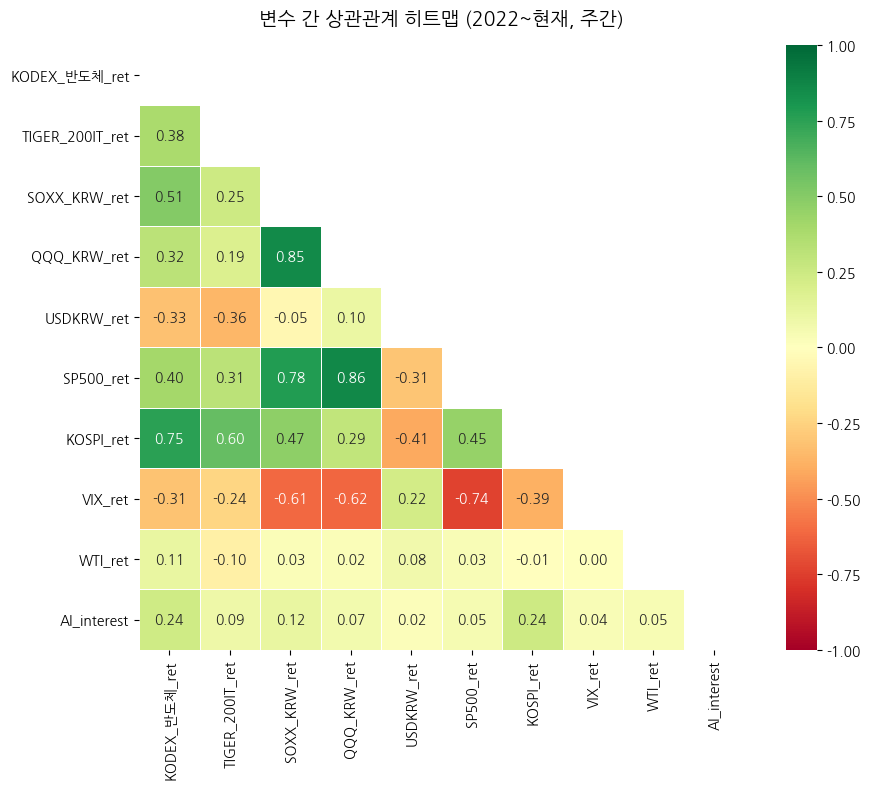

✅ 히트맵 저장 완료: corr_heatmap.png

⚠️  주목할 부분: SP500_ret ↔ KOSPI_ret 상관계수가 높으면 VIF 심각


In [10]:
# ════════════════════════════════════════════════════════
# STEP 8 — 상관관계 히트맵 (보고서 제출용)
# ════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 8))

PLOT_COLS = [
    'KODEX_반도체_ret', 'TIGER_200IT_ret',
    'SOXX_KRW_ret', 'QQQ_KRW_ret',
    'USDKRW_ret', 'SP500_ret', 'KOSPI_ret',
    'VIX_ret', 'WTI_ret', 'AI_interest'
]

corr = analysis[PLOT_COLS].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # 상삼각 마스크

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('변수 간 상관관계 히트맵 (2022~현재, 주간)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 히트맵 저장 완료: corr_heatmap.png')
print('\n⚠️  주목할 부분: SP500_ret ↔ KOSPI_ret 상관계수가 높으면 VIF 심각')

In [11]:
# ════════════════════════════════════════════════════════
# STEP 9 — 최종 체크리스트 출력
# ════════════════════════════════════════════════════════

print('=' * 50)
print('       이번 주 완성 체크리스트')
print('=' * 50)

checks = {
    'DataFrame (10변수 × 약 170행)': len(analysis) > 100,
    'Google Trends 병합':            'AI_interest' in analysis.columns,
    '원화 환산 수익률 계산':          'SOXX_KRW_ret' in analysis.columns,
    '시장 국면 라벨링':               'phase' in analysis.columns,
    'VIF 진단 완료':                  True,
    '상관관계 히트맵 저장':           True,
}

for item, passed in checks.items():
    icon = '✅' if passed else '❌'
    print(f'  {icon} {item}')

print('=' * 50)
print(f'\n📊 최종 데이터 shape: {analysis.shape}')
print(f'📅 기간: {analysis.index[0].date()} ~ {analysis.index[-1].date()}')
print('\n다음 단계: OLS 다중회귀 분석 (02_regression.ipynb)')

       이번 주 완성 체크리스트
  ✅ DataFrame (10변수 × 약 170행)
  ✅ Google Trends 병합
  ✅ 원화 환산 수익률 계산
  ✅ 시장 국면 라벨링
  ✅ VIF 진단 완료
  ✅ 상관관계 히트맵 저장

📊 최종 데이터 shape: (224, 11)
📅 기간: 2022-01-14 ~ 2026-04-24

다음 단계: OLS 다중회귀 분석 (02_regression.ipynb)
